# Demo

A demostration script for the ECLYPSE network simulator extension.

This script validates the implementation of the queuing model,
physical link parameters, and routing tables by simulating a "bottleneck"
scenario.

It sets up a topology:

- Sensor → Gateway
- Gateway → R1
- Gateway → R2
- R1 → R2
- R1 → R3
- R2 → R3
- R3 → Cloud

It defines traffic flows,
and measures the end-to-end packet delays to demonstrate the emergence of
queuing congestion.

In [1]:
import time
from eclypse.remote.service import Service
from network import Network
from network_application import NetworkAwareApplication
from eclypse.simulation.config import SimulationConfig
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

In [2]:
from eclypse.placement.strategies import StaticStrategy
from traffic_metric import TrafficRoutingMetric
from packet_generation import PacketGenerationEvent
from traffic_event import TrafficRoutingExecutionEvent
from eclypse.simulation import Simulation
from eclypse.utils.defaults import DEFAULT_EDGE_LATENCY

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")

infrastructure_nodes = ["Sensor", "Gateway", "R1", "R2", "R3", "Cloud"]
for node in infrastructure_nodes:
    infra.add_node(node)

# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10)

# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50)


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)


app.add_edge("Sensor1",
             "Cloud1",
             packet_size_bytes=1500,
             packets_per_step=1,
             bandwidth=0,
             latency=1000
            )


packet_event = PacketGenerationEvent()

execution_event = TrafficRoutingExecutionEvent(step_duration_s=0.0005)
reporting_metric = TrafficRoutingMetric(step_duration_s=0.0005)

sim_config = SimulationConfig(
    seed=42,
    max_steps=101,
    step_every_ms=500,
    path="./results",
    events=[packet_event, execution_event, reporting_metric],
    include_default_metrics=False,
    report_format="json",
    report_backend="pandas",
    remote=False
)

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({
    "Sensor1": "Sensor",
    "Cloud1": "Cloud"
})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

1. Setting up Infrastructure...
2. Setting up Application (Video Stream)...
17:21:37.278 | WARNING | IoT_Network - [OSPF] Cache invalidated.
3. Initializing Simulation...
17:21:37.279 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.279 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.279 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.279 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.279 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.280 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.280 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.280 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.281 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.281 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.281 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.281 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:21:37.283 | INFO | VideoApp - Added edge flow 

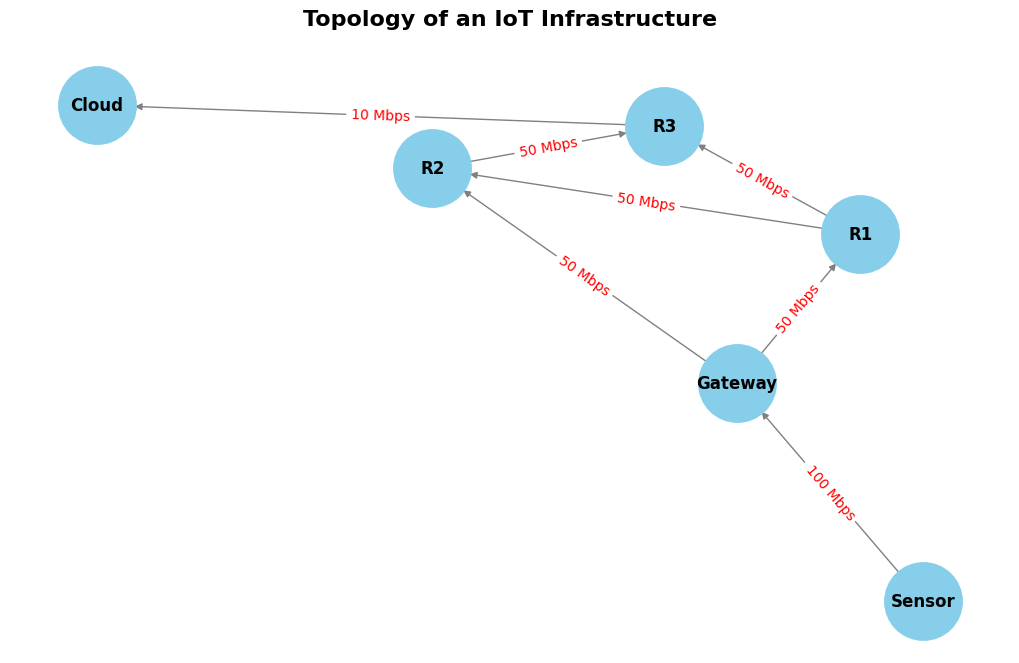

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a NetworkX graph from the infrastructure
plt.figure(figsize=(10, 6))

# Calculate the positions of the nodes using the spring layout algorithm
pos = nx.spring_layout(infra, seed=42)

# Draw the network with custom styling
nx.draw(
    infra,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=3000,
    font_size=12,
    font_weight='bold',
    edge_color='gray',
    linewidths=2
)

# print the bandwidth on the edges using the 'bandwidth_mbps' attribute
edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    # add "Mbps" to the bandwidth values for better readability
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of an IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off')  # Hide axes for better visualization
plt.show()

--- HOP CHRONOLOGICAL LOG ---
[  0.000725s] | Packet: 1    | Link:  Sensor->Gateway  | Queue:  0 pkts
[  0.001090s] | Packet: 1    | Link:    Gateway->R1    | Queue:  0 pkts
[  0.001225s] | Packet: 2    | Link:  Sensor->Gateway  | Queue:  0 pkts
[  0.001480s] | Packet: 1    | Link:      R1->R3       | Queue:  0 pkts
[  0.001590s] | Packet: 2    | Link:    Gateway->R1    | Queue:  0 pkts
[  0.001725s] | Packet: 3    | Link:  Sensor->Gateway  | Queue:  0 pkts
[  0.001980s] | Packet: 2    | Link:      R1->R3       | Queue:  0 pkts
[  0.002090s] | Packet: 3    | Link:    Gateway->R1    | Queue:  0 pkts
[  0.002225s] | Packet: 4    | Link:  Sensor->Gateway  | Queue:  0 pkts
[  0.002480s] | Packet: 3    | Link:      R1->R3       | Queue:  0 pkts
[  0.002590s] | Packet: 4    | Link:    Gateway->R1    | Queue:  0 pkts
[  0.002725s] | Packet: 5    | Link:  Sensor->Gateway  | Queue:  0 pkts
[  0.002980s] | Packet: 4    | Link:      R1->R3       | Queue:  0 pkts
[  0.003030s] | Packet: 1    | Lin

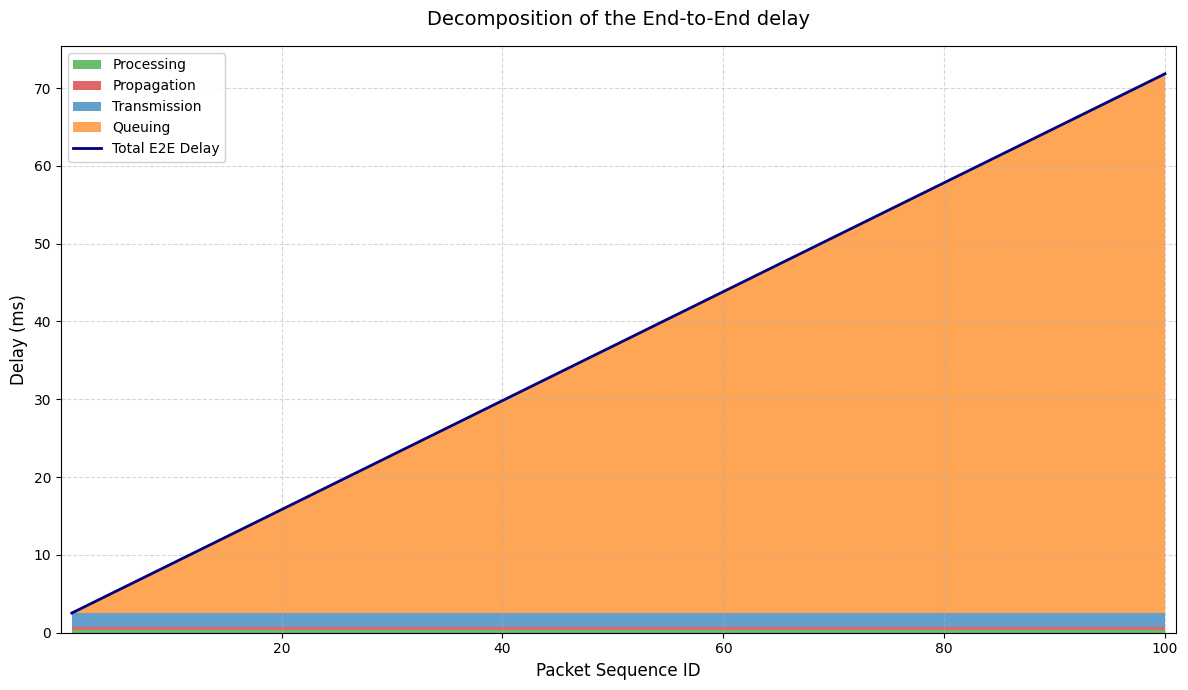


Breakdown of the last packet (ID 100):
- Processing:   0.4000 ms
- Propagation:  0.3300 ms
- Transmission: 1.8000 ms
- Queuing:      69.3000 ms
--------------------------------
= TOTAL E2E:    71.8300 ms


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import json

# Openining of the JSONL file and extracting the relevant metrics
json_path = "./results/json/application.jsonl"
records = []

with open(json_path, 'r') as file:
    for line in file:
        if line.strip():
            # Extract only valid [app_id, metric, value] triples
            metrics = [m for m in json.loads(line).get("data", []) if len(m) == 3]
            for app_id, metric_name, val in metrics:
                records.append({'metric': str(metric_name), 'val': val})

df_raw = pd.DataFrame(records)
# Extract the Hop metrics and extract ID, Hop Num and Field Name
df_hops = df_raw[df_raw['metric'].str.contains("_Hop_")].copy()
extracted = df_hops['metric'].str.extract(r'pkt_(\d+)_Hop_(\d+)_(.*)')
df_hops['Packet_ID'] = extracted[0].astype(int)
df_hops['Hop_ID'] = extracted[1].astype(int)
df_hops['Field'] = extracted[2]

# Create a clean table where each row is a HOP, and the columns are the delays
df_pivot = df_hops.pivot_table(
    index=['Packet_ID', 'Hop_ID'], columns='Field', values='val', aggfunc='first'
).reset_index()

# Convert the fields to numeric values
numeric_cols = ['arrival_at_next', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
for col in numeric_cols:
    if col in df_pivot.columns:
        df_pivot[col] = pd.to_numeric(df_pivot[col])

df_pivot['queue_length'] = pd.to_numeric(df_pivot.get('queue_length', 0)).fillna(0).astype(int)

print("--- HOP CHRONOLOGICAL LOG ---")
# Sort the table by arrival time and print it
df_log = df_pivot.sort_values('arrival_at_next')
for _, row in df_log.iterrows():
    print(f"[{row['arrival_at_next']:10.6f}s] | Packet: {row['Packet_ID']:<4} | Link: {row['hop']:^17} | Queue: {row['queue_length']:>2} pkts")


# Sum automatically the delays grouping by Packet_ID
df_agg = df_pivot.groupby('Packet_ID')[
    ['processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
].sum().reset_index()

# Retrieve the Total_Delay for each packet
df_total = df_raw[df_raw['metric'].str.contains("Total_Delay_ms")].copy()
df_total['Packet_ID'] = df_total['metric'].str.extract(r'pkt_(\d+)').astype(int)
df_total = df_total[['Packet_ID', 'val']].rename(columns={'val': 'Total_Delay_ms'})

# Merge the aggregated delays with the total delay for plotting
df_plot = pd.merge(df_agg, df_total, on='Packet_ID').sort_values('Packet_ID')

# Graph creation
plt.figure(figsize=(12, 7))
plt.stackplot(
    df_plot['Packet_ID'],
    df_plot['processing_ms'],
    df_plot['propagation_ms'],
    df_plot['transmission_ms'],
    df_plot['queue_ms'],
    labels=['Processing', 'Propagation', 'Transmission', 'Queuing'],
    colors=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], alpha=0.7
)

plt.plot(df_plot['Packet_ID'], df_plot['Total_Delay_ms'], color='navy', linewidth=2, label='Total E2E Delay')
plt.title("Decomposition of the End-to-End delay", fontsize=14, pad=15)
plt.xlabel("Packet Sequence ID", fontsize=12)
plt.ylabel("Delay (ms)", fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.margins(x=0.01)
plt.tight_layout()
plt.show()

# View the breakdown of the last packet
last_pkt = df_plot.iloc[-1]

print(f"\nBreakdown of the last packet (ID {int(last_pkt['Packet_ID'])}):")
print(f"- Processing:   {last_pkt['processing_ms']:.4f} ms")
print(f"- Propagation:  {last_pkt['propagation_ms']:.4f} ms")
print(f"- Transmission: {last_pkt['transmission_ms']:.4f} ms")
print(f"- Queuing:      {last_pkt['queue_ms']:.4f} ms")
print(f"--------------------------------")
print(f"= TOTAL E2E:    {last_pkt['Total_Delay_ms']:.4f} ms")

# Failure recovery

In [5]:
import time
from eclypse.remote.service import Service
from network import Network
from network_application import NetworkAwareApplication
from eclypse.simulation.config import SimulationConfig
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

In [6]:
from eclypse.placement.strategies import StaticStrategy
from traffic_event import TrafficRoutingExecutionEvent
from traffic_metric import TrafficRoutingMetric
from packet_generation import PacketGenerationEvent
from fault_injection import FaultInjectionEvent
from eclypse.simulation import Simulation

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")
infrastructure_nodes = ["Sensor", "Gateway", "R1", "R2", "R3", "Cloud"]
for node in infrastructure_nodes:
    infra.add_node(node)

# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_edge("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_edge("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_edge("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_edge("R2", "R3", bandwidth_mbps=50, length_km=10)
# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50)


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)


app.add_edge(
    "Sensor1", "Cloud1", packet_size_bytes=1500, packets_per_step=1, bandwidth=0, latency=1000
)

packet_event = PacketGenerationEvent()
traffic_event = TrafficRoutingExecutionEvent(step_duration_s=0.0005)
traffic_metric = TrafficRoutingMetric(step_duration_s=0.0005)

sim_config = SimulationConfig(
    seed=42,
    max_steps=101,
    step_every_ms=500,
    path="./results-20260511_160749",
    events=[packet_event, traffic_event, traffic_metric, FaultInjectionEvent],
    include_default_metrics=False,
    report_format="json",
    report_backend="pandas",
    remote=False,
)

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({"Sensor1": "Sensor", "Cloud1": "Cloud"})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

1. Setting up Infrastructure...
2. Setting up Application (Video Stream)...
17:22:27.939 | WARNING | IoT_Network - [OSPF] Cache invalidated.
3. Initializing Simulation...
17:22:27.940 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.940 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.940 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.940 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.940 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.941 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.941 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.941 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.942 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.942 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.942 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.942 | WARNING | IoT_Network - [OSPF] Cache invalidated.
17:22:27.943 | INFO | VideoApp - Added edge flow 

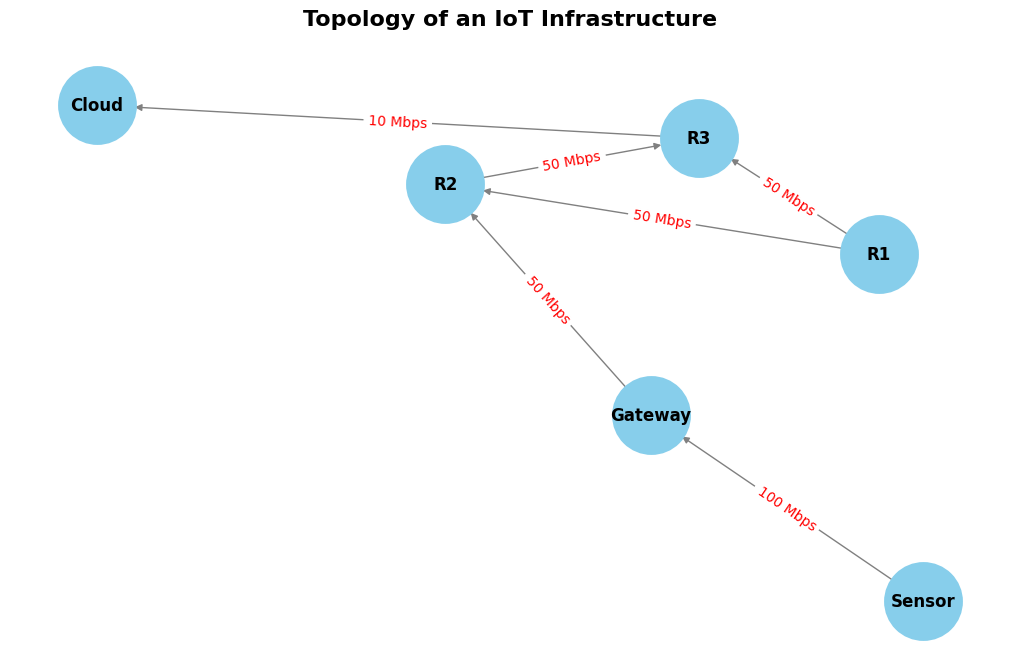

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

pos = nx.spring_layout(infra, seed=42)

nx.draw(
    infra,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=3000,
    font_size=12,
    font_weight='bold',
    edge_color='gray',
    linewidths=2
)

edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    formatted_labels = {edge: f"{bw} Mbps" for edge, bw in edge_labels.items()}
    nx.draw_networkx_edge_labels(infra, pos, edge_labels=formatted_labels, font_color='red')

plt.title("Topology of an IoT Infrastructure", fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.show()

--- HOP CHRONOLOGICAL LOG ---
[  0.000725s] | Packet: 1    | Link:  Sensor->Gateway  | Queue:  0 pkts
[  0.001090s] | Packet: 1    | Link:    Gateway->R1    | Queue:  0 pkts
[  0.001225s] | Packet: 2    | Link:  Sensor->Gateway  | Queue:  0 pkts
[  0.001480s] | Packet: 1    | Link:      R1->R3       | Queue:  0 pkts
[  0.001590s] | Packet: 2    | Link:    Gateway->R1    | Queue:  0 pkts
[  0.001725s] | Packet: 3    | Link:  Sensor->Gateway  | Queue:  0 pkts
[  0.001980s] | Packet: 2    | Link:      R1->R3       | Queue:  0 pkts
[  0.002090s] | Packet: 3    | Link:    Gateway->R1    | Queue:  0 pkts
[  0.002225s] | Packet: 4    | Link:  Sensor->Gateway  | Queue:  0 pkts
[  0.002480s] | Packet: 3    | Link:      R1->R3       | Queue:  0 pkts
[  0.002590s] | Packet: 4    | Link:    Gateway->R1    | Queue:  0 pkts
[  0.002725s] | Packet: 5    | Link:  Sensor->Gateway  | Queue:  0 pkts
[  0.002980s] | Packet: 4    | Link:      R1->R3       | Queue:  0 pkts
[  0.003030s] | Packet: 1    | Lin

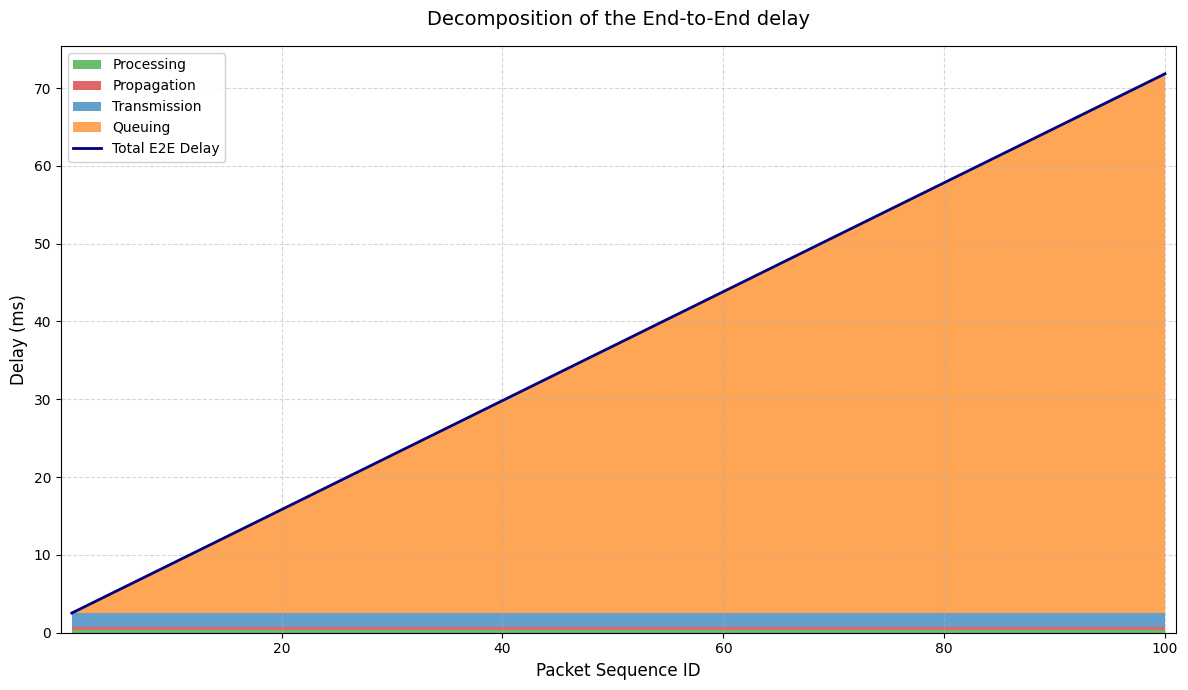


Breakdown of the last packet (ID 100):
- Processing:   0.4000 ms
- Propagation:  0.3300 ms
- Transmission: 1.8000 ms
- Queuing:      69.3000 ms
--------------------------------
= TOTAL E2E:    71.8300 ms


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import json
# Openining of the JSONL file and extracting the relevant metrics
json_path = "./results-20260511_160749/json/application.jsonl"
records = []

with open(json_path, 'r') as file:
    for line in file:
        if line.strip():
            # Extract only valid [app_id, metric, value] triples
            metrics = [m for m in json.loads(line).get("data", []) if len(m) == 3]
            for app_id, metric_name, val in metrics:
                records.append({'metric': str(metric_name), 'val': val})

df_raw = pd.DataFrame(records)
# Extract the Hop metrics and extract ID, Hop Num and Field Name
df_hops = df_raw[df_raw['metric'].str.contains("_Hop_")].copy()
extracted = df_hops['metric'].str.extract(r'pkt_(\d+)_Hop_(\d+)_(.*)')
df_hops['Packet_ID'] = extracted[0].astype(int)
df_hops['Hop_ID'] = extracted[1].astype(int)
df_hops['Field'] = extracted[2]

# Create a clean table where each row is a HOP, and the columns are the delays
df_pivot = df_hops.pivot_table(
    index=['Packet_ID', 'Hop_ID'], columns='Field', values='val', aggfunc='first'
).reset_index()

# Convert the fields to numeric values
numeric_cols = ['arrival_at_next', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
for col in numeric_cols:
    if col in df_pivot.columns:
        df_pivot[col] = pd.to_numeric(df_pivot[col])

df_pivot['queue_length'] = pd.to_numeric(df_pivot.get('queue_length', 0)).fillna(0).astype(int)

print("--- HOP CHRONOLOGICAL LOG ---")
# Sort the table by arrival time and print it
df_log = df_pivot.sort_values('arrival_at_next')
for _, row in df_log.iterrows():
    print(f"[{row['arrival_at_next']:10.6f}s] | Packet: {row['Packet_ID']:<4} | Link: {row['hop']:^17} | Queue: {row['queue_length']:>2} pkts")


# Sum automatically the delays grouping by Packet_ID
df_agg = df_pivot.groupby('Packet_ID')[
    ['processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
].sum().reset_index()

# Retrieve the Total_Delay for each packet
df_total = df_raw[df_raw['metric'].str.contains("Total_Delay_ms")].copy()
df_total['Packet_ID'] = df_total['metric'].str.extract(r'pkt_(\d+)').astype(int)
df_total = df_total[['Packet_ID', 'val']].rename(columns={'val': 'Total_Delay_ms'})

# Merge the aggregated delays with the total delay for plotting
df_plot = pd.merge(df_agg, df_total, on='Packet_ID').sort_values('Packet_ID')

# Graph creation
plt.figure(figsize=(12, 7))
plt.stackplot(
    df_plot['Packet_ID'],
    df_plot['processing_ms'],
    df_plot['propagation_ms'],
    df_plot['transmission_ms'],
    df_plot['queue_ms'],
    labels=['Processing', 'Propagation', 'Transmission', 'Queuing'],
    colors=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], alpha=0.7
)

plt.plot(df_plot['Packet_ID'], df_plot['Total_Delay_ms'], color='navy', linewidth=2, label='Total E2E Delay')
plt.title("Decomposition of the End-to-End delay", fontsize=14, pad=15)
plt.xlabel("Packet Sequence ID", fontsize=12)
plt.ylabel("Delay (ms)", fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.margins(x=0.01)
plt.tight_layout()
plt.show()

# View the breakdown of the last packet
last_pkt = df_plot.iloc[-1]

print(f"\nBreakdown of the last packet (ID {int(last_pkt['Packet_ID'])}):")
print(f"- Processing:   {last_pkt['processing_ms']:.4f} ms")
print(f"- Propagation:  {last_pkt['propagation_ms']:.4f} ms")
print(f"- Transmission: {last_pkt['transmission_ms']:.4f} ms")
print(f"- Queuing:      {last_pkt['queue_ms']:.4f} ms")
print(f"--------------------------------")
print(f"= TOTAL E2E:    {last_pkt['Total_Delay_ms']:.4f} ms")